<a href="https://colab.research.google.com/github/Abid-Hossain29130/Abid-Hossain29130/blob/main/Abid_Hossain_Project1_Palmer_Penguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the palmerpenguins package (run only once in Colab)
!pip install palmerpenguins

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from palmerpenguins import load_penguins
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = load_penguins()
print("Dataset Shape:", df.shape)
print(df.head())
print("\nData Types:\n", df.dtypes)
print("\nTarget Classes:", df['species'].unique())

Dataset Shape: (344, 8)
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  

Data Types:
 species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

Target Classes: ['Adelie' 'Gentoo' 'Chinstrap']


In [ ]:
print(df.describe())
print("\nMissing Values:\n", df.isnull().sum())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   344.000000  
mean   2008.029070  
std       0.818356  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  

Missing Values:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2


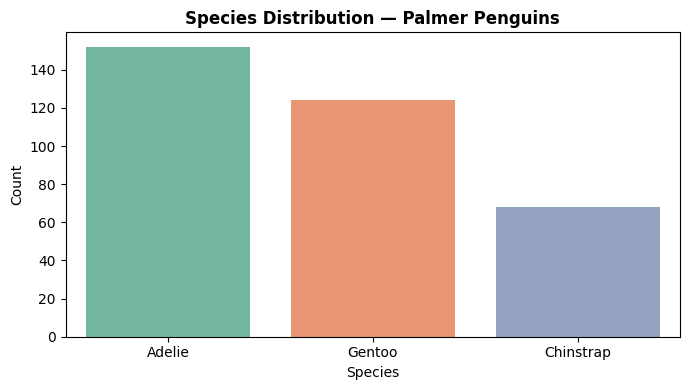

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='species', data=df, palette='Set2')
plt.title('Species Distribution — Palmer Penguins', fontweight='bold')
plt.xlabel('Species'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

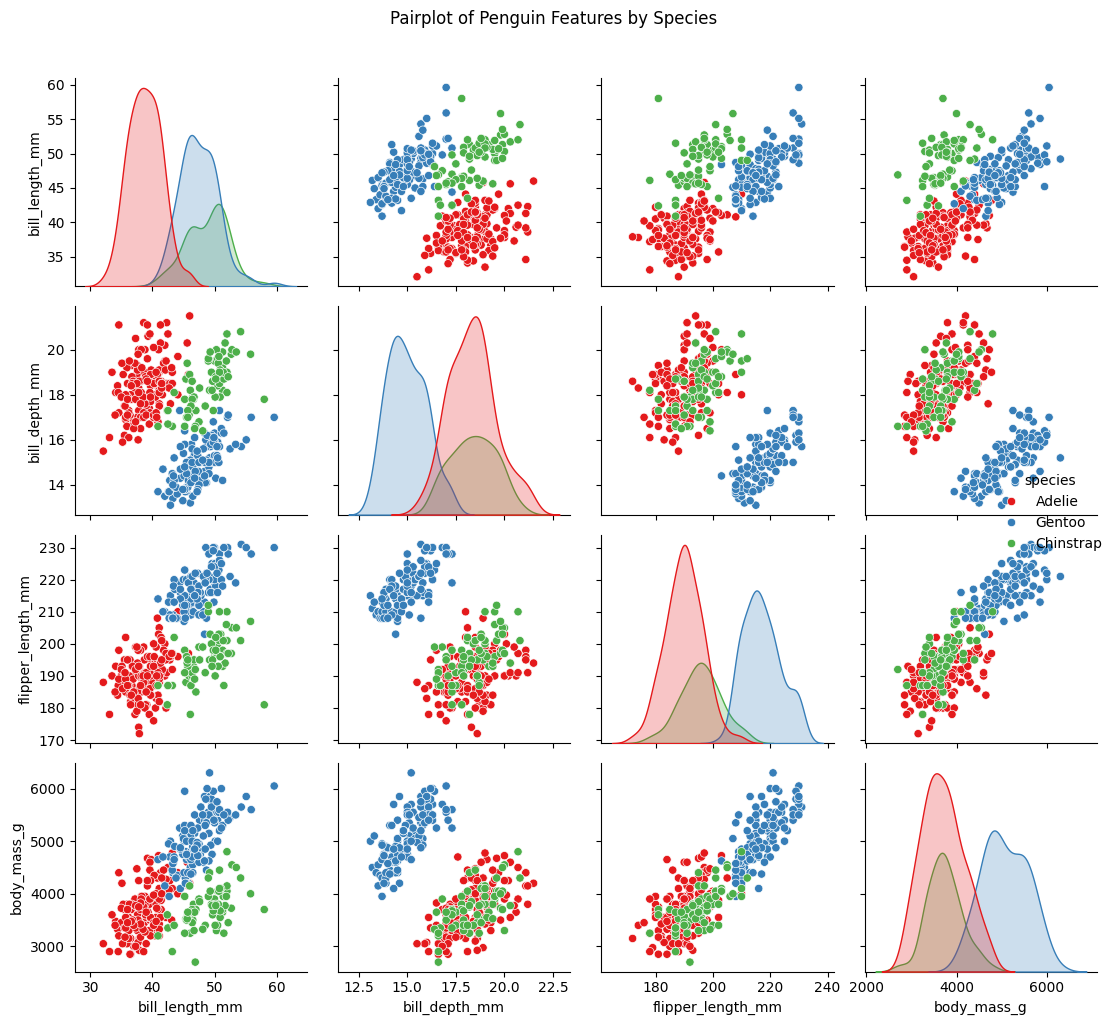

In [ ]:
sns.pairplot(df, hue='species', palette='Set1',
             vars=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'])
plt.suptitle('Pairplot of Penguin Features by Species', y=1.02)
plt.tight_layout(); plt.show()

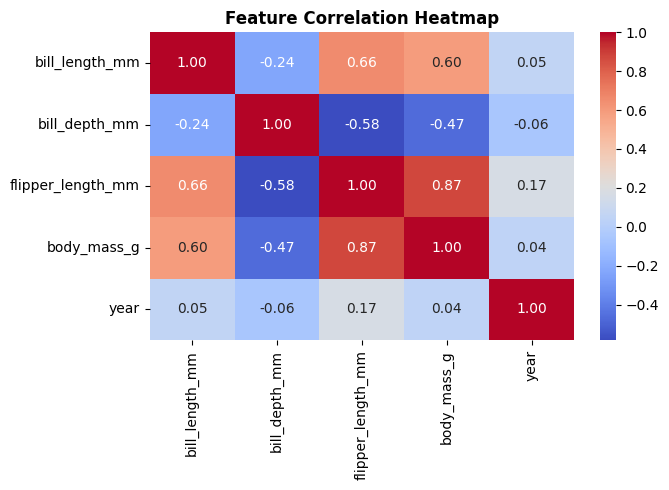

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

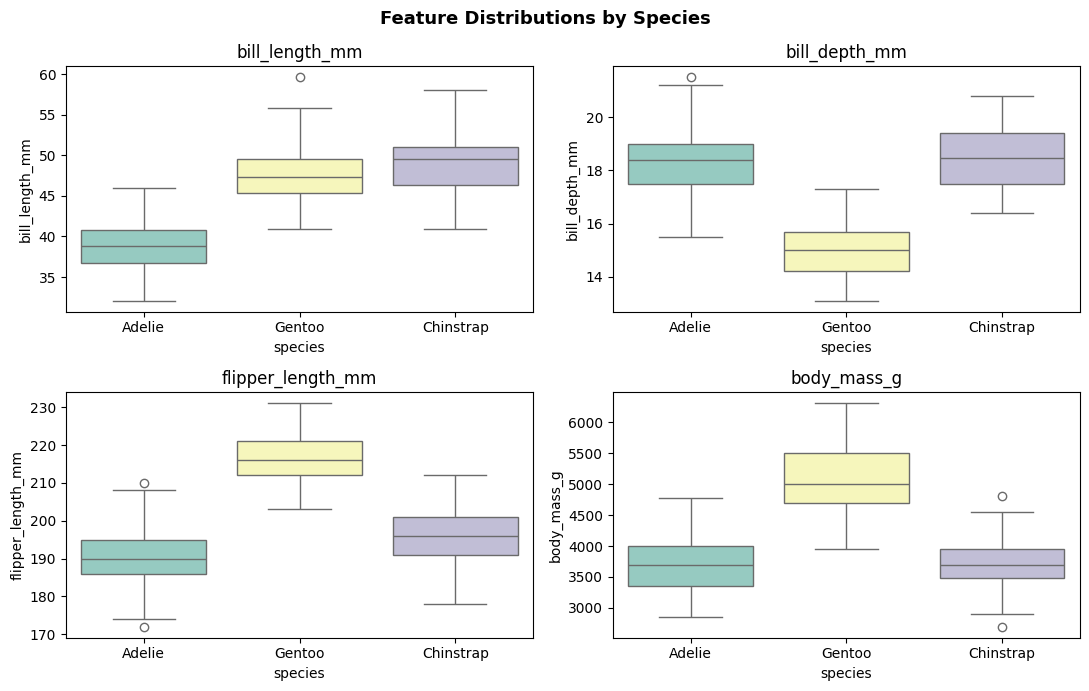

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(11,7))
for ax, feat in zip(axes.flat, ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']):
    sns.boxplot(x='species', y=feat, data=df, palette='Set3', ax=ax)
    ax.set_title(feat)
plt.suptitle('Feature Distributions by Species', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
df_clean = df.dropna().copy()
print(f"Rows before: {len(df)} | Rows after: {len(df_clean)} | Removed: {len(df)-len(df_clean)}")

le = LabelEncoder()
df_clean['species_enc'] = le.fit_transform(df_clean['species'])
df_clean['island_enc']  = le.fit_transform(df_clean['island'])
df_clean['sex_enc']     = le.fit_transform(df_clean['sex'])
print("Encoding complete:", dict(zip(le.classes_, le.transform(le.classes_))))



Rows before: 344 | Rows after: 333 | Removed: 11
Encoding complete: {'female': np.int64(0), 'male': np.int64(1)}


In [ ]:
X = df_clean[['bill_length_mm','bill_depth_mm','flipper_length_mm',
              'body_mass_g','island_enc','sex_enc']]
y = df_clean['species_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 266 samples | Test: 67 samples


In [ ]:
models = {
    'Logistic Regression':  LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                  SVC(kernel='rbf', random_state=42),
    'KNN':                  KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'CV-5fold':  round(cross_val_score(model, X_train_s, y_train, cv=5).mean(), 4)
    })

In [ ]:
# --- STEP 7 CODE (Run this in Colab) ---
import pandas as pd

# This turns your 'results' bucket into a visible table
res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
res_df.index += 1

# This is the magic line that makes the output appear on your screen
print(res_df.to_string())

                 Model  Accuracy  Precision  Recall  F1-Score  CV-5fold
1  Logistic Regression    1.0000     1.0000  1.0000    1.0000    0.9925
2                  SVM    1.0000     1.0000  1.0000    1.0000    0.9962
3                  KNN    0.9851     0.9861  0.9851    0.9852    0.9887
4        Random Forest    0.9851     0.9861  0.9851    0.9852    0.9811
5    Gradient Boosting    0.9701     0.9739  0.9701    0.9705    0.9925
6        Decision Tree    0.9403     0.9477  0.9403    0.9414    0.9586


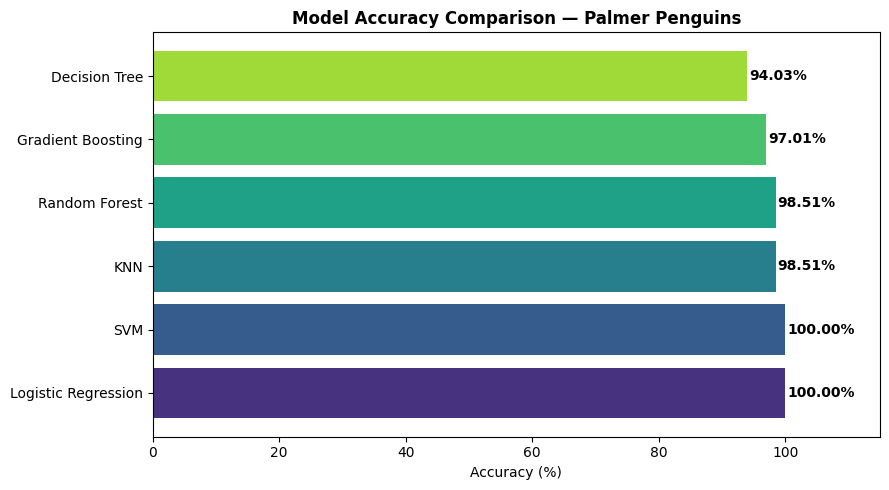

In [ ]:
res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
plt.figure(figsize=(9,5))
bars = plt.barh(res_df['Model'], res_df['Accuracy']*100,
                color=sns.color_palette('viridis', 6))
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracy Comparison — Palmer Penguins', fontweight='bold')
for b, v in zip(bars, res_df['Accuracy']*100):
    plt.text(b.get_width()+0.3, b.get_y()+b.get_height()/2,
             f'{v:.2f}%', va='center', fontweight='bold')
plt.xlim(0, 115); plt.tight_layout(); plt.show()

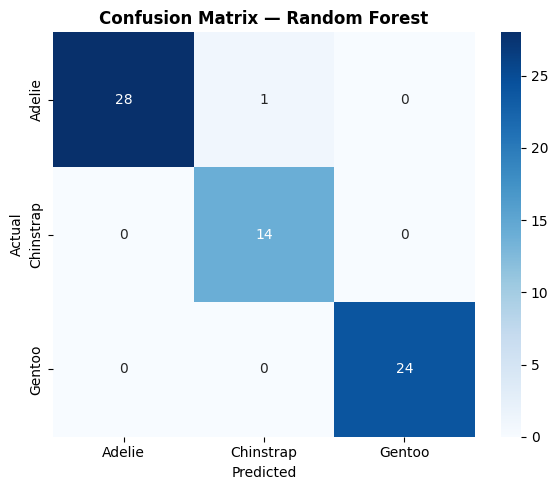

In [ ]:
best = models['Random Forest']
cm = confusion_matrix(y_test, best.predict(X_test_s))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Adelie','Chinstrap','Gentoo'],
            yticklabels=['Adelie','Chinstrap','Gentoo'])
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

In [ ]:
print(classification_report(y_test, best.predict(X_test_s),
      target_names=['Adelie','Chinstrap','Gentoo']))

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [ ]:

# Create hypothetical new penguin data
new_penguin = pd.DataFrame([{
    'bill_length_mm': 39.5,
    'bill_depth_mm': 17.5,
    'flipper_length_mm': 190.0,
    'body_mass_g': 3500.0,
    'island_enc': 2, # Torgersen
    'sex_enc': 1     # Male
}])

# Use the Best Model (Random Forest) to predict
pred_enc = best.predict(new_penguin)
pred_species = le.inverse_transform(pred_enc)

print(f"New Penguin Data for Prediction:\n", new_penguin)
print(f"\nPredicted Species: {pred_species[0]}")

New Penguin Data for Prediction:
    bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  island_enc  \
0            39.5           17.5              190.0       3500.0           2   

   sex_enc  
0        1  

Predicted Species: male
